# Issue #130 — портфель 50k `levels_sr_support`
Кандидаты isolated C из #129 (`levels_sr_support` + `signal_4h_buy`) на общем капитале 50,000 RUB по слотам #44/#103. Ноутбук загружает прогон, проверяет SHA конфига и слоты, строит метрики и воспроизводит артефакты отчёта. Exclusive B-support 3811/1.51 и #124 B-mix не смешиваются с C.

In [1]:
from pathlib import Path
import sys
from IPython.display import display, Markdown, Image

ANALYSIS_DIR = Path.cwd()
if not (ANALYSIS_DIR / 'analysis.py').exists():
    ANALYSIS_DIR = Path('analytics/issue-130-sr-support-portfolio').resolve()
sys.path.insert(0, str(ANALYSIS_DIR))
from analysis import run_analysis, DISPLAY_NAME

## Расчёт
`run_analysis()` валидирует SHA конфига C, слоты 50k/10k/max 5, n кандидатов 4380 и покрытие 2026-08-20. Daily equity — по закрытым сделкам (без mark-to-market). Бар ALRS paper #711 во входах — блокер.

In [2]:
analysis = run_analysis()
analysis['metrics']

strategy                          levels_sr_support
final_equity_rub                           96204.63
pnl_rub                                    46204.63
pnl_pct                                       92.41
n_trades                                       3237
win_rate_pct                                   28.7
profit_factor                                  1.33
event_max_drawdown_pct                         6.98
game_over                                     False
skipped_entries                                1143
candidate_trades                               4380
max_drawdown_pct                               6.08
max_drawdown_peak_date                   2025-02-17
max_drawdown_trough_date                 2025-03-13
max_drawdown_peak_equity_rub               66889.89
max_drawdown_trough_equity_rub             62820.64
max_drawdown_rub                            4069.25
dtype: object

## Конфиг и вселенная

In [3]:
result = analysis['result']
{
    'strategy_config_name': result.get('strategy_config_name'),
    'config_sha256': result.get('config_sha256'),
    'plugin': result.get('strategy'),
    'in_paper_test': result.get('in_paper_test'),
    'locked': result.get('locked'),
    'date_from': result.get('date_from'),
    'date_to': result.get('date_to'),
    'period_last_day': result.get('period_last_day'),
    'candidate_trades': result.get('candidate_trades'),
    'tickers_volume_order': result.get('tickers_volume_order'),
    'sha256': analysis['hash'],
}

{'strategy_config_name': 'levels_sr_support',
 'config_sha256': '3b7864c4de2cb2c7d271be8c21c7d99c29bfd8a7dd05980b3c5497b6b2aedb1b',
 'plugin': 'levels_reversal',
 'in_paper_test': False,
 'locked': False,
 'date_from': '2024-08-01',
 'date_to': '2026-08-21',
 'period_last_day': '2026-08-20',
 'candidate_trades': 4380,
 'tickers_volume_order': ['FEES',
  'IRAO',
  'AFKS',
  'VTBR',
  'GAZP',
  'SNGS',
  'SBER',
  'RUAL',
  'ALRS',
  'GMKN',
  'MTLR',
  'CBOM',
  'NLMK',
  'ROSN',
  'RTKM',
  'MOEX',
  'FLOT',
  'MTSS',
  'NVTK',
  'PIKK',
  'TATN',
  'CHMF',
  'SIBN',
  'PLZL',
  'LKOH',
  'TRNFP',
  'MGNT',
  'PHOR'],
 'sha256': '0c2ccb5f8cbbd3f8438a050daa6de17f77628d05229ae6ea6aa30df310da8921'}

## Equity-кривая

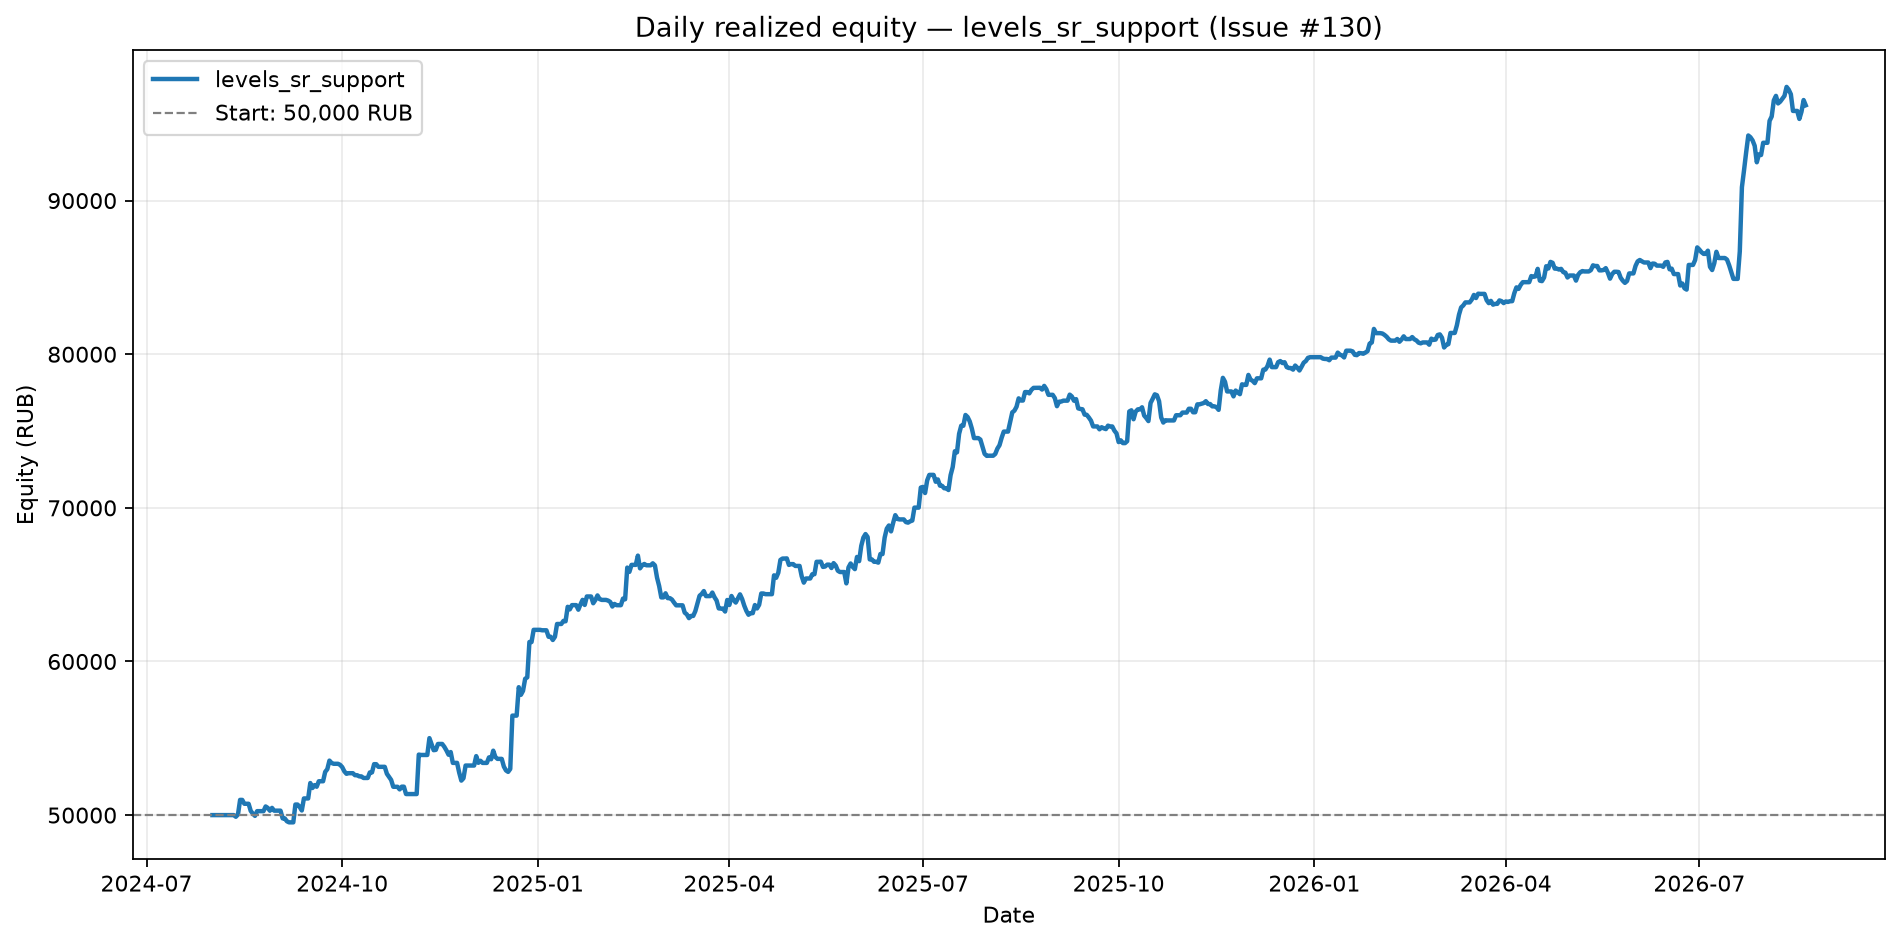

In [4]:
display(Image(filename=str(ANALYSIS_DIR / 'plots/equity_curves.png')))

## Распределение PnL сделок

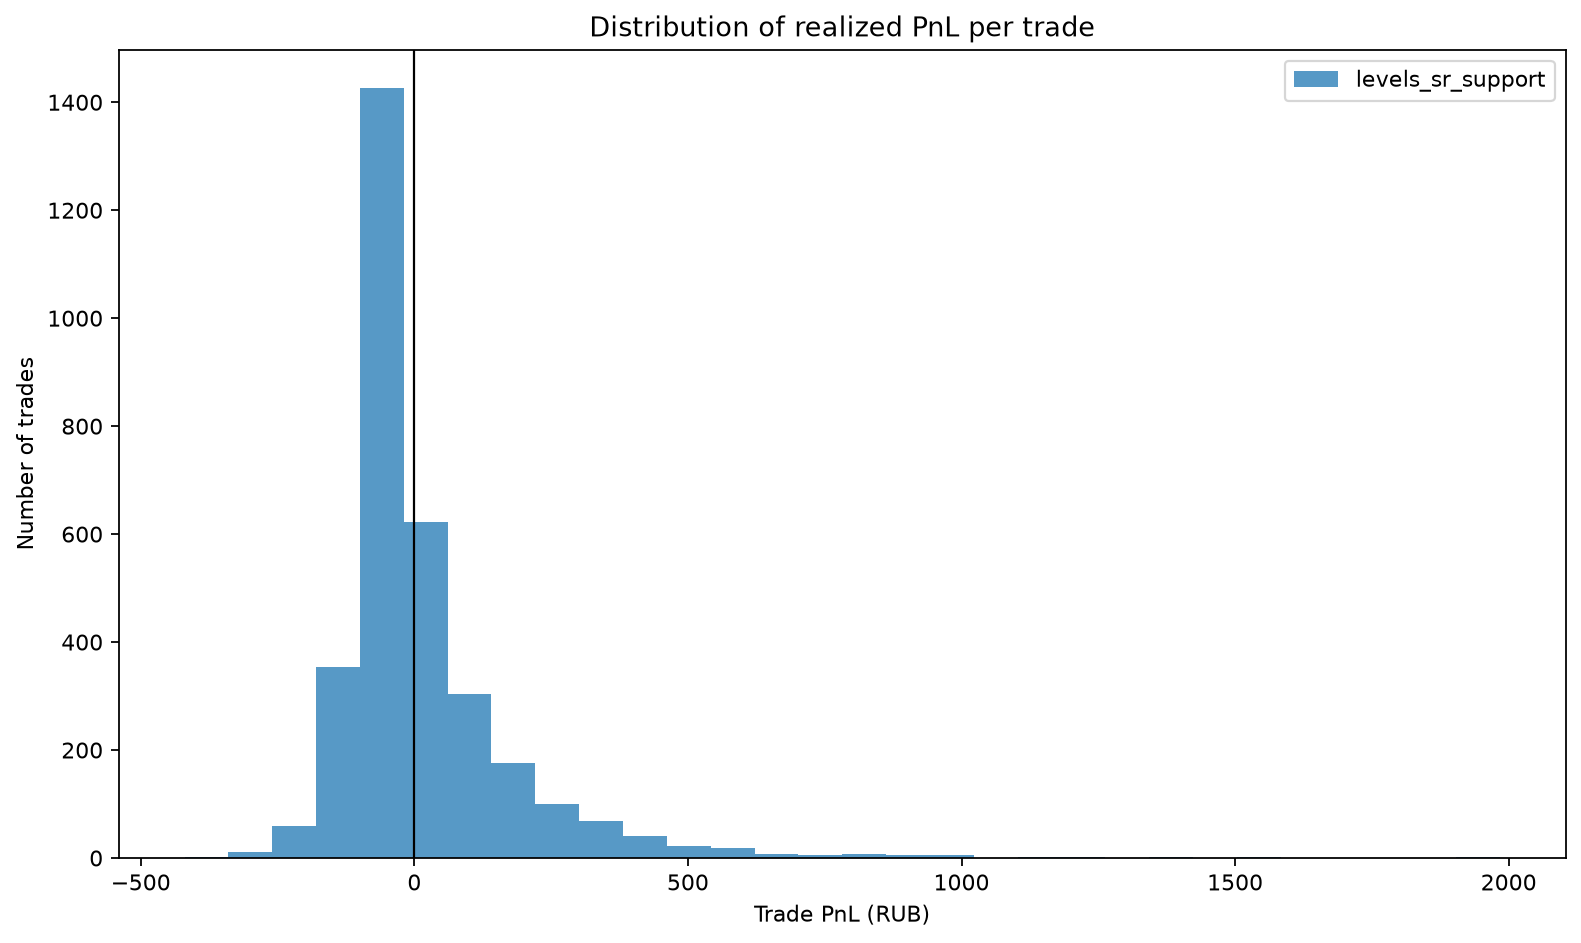

In [5]:
display(Image(filename=str(ANALYSIS_DIR / 'plots/trade_pnl_distribution.png')))

## Результаты по тикерам

,ticker,n_trades,pnl_rub,win_rate_pct
0,AFKS,61,2169.03,31.147541
1,ALRS,114,1181.33,26.315789
2,CBOM,209,3011.99,29.665072
3,CHMF,75,-57.75,17.333333
4,FEES,119,272.61,24.369748
5,FLOT,200,2842.73,28.500000
6,GAZP,77,1535.00,37.662338
7,GMKN,91,3323.66,31.868132
8,IRAO,137,2424.68,32.846715
9,LKOH,96,2014.96,29.166667


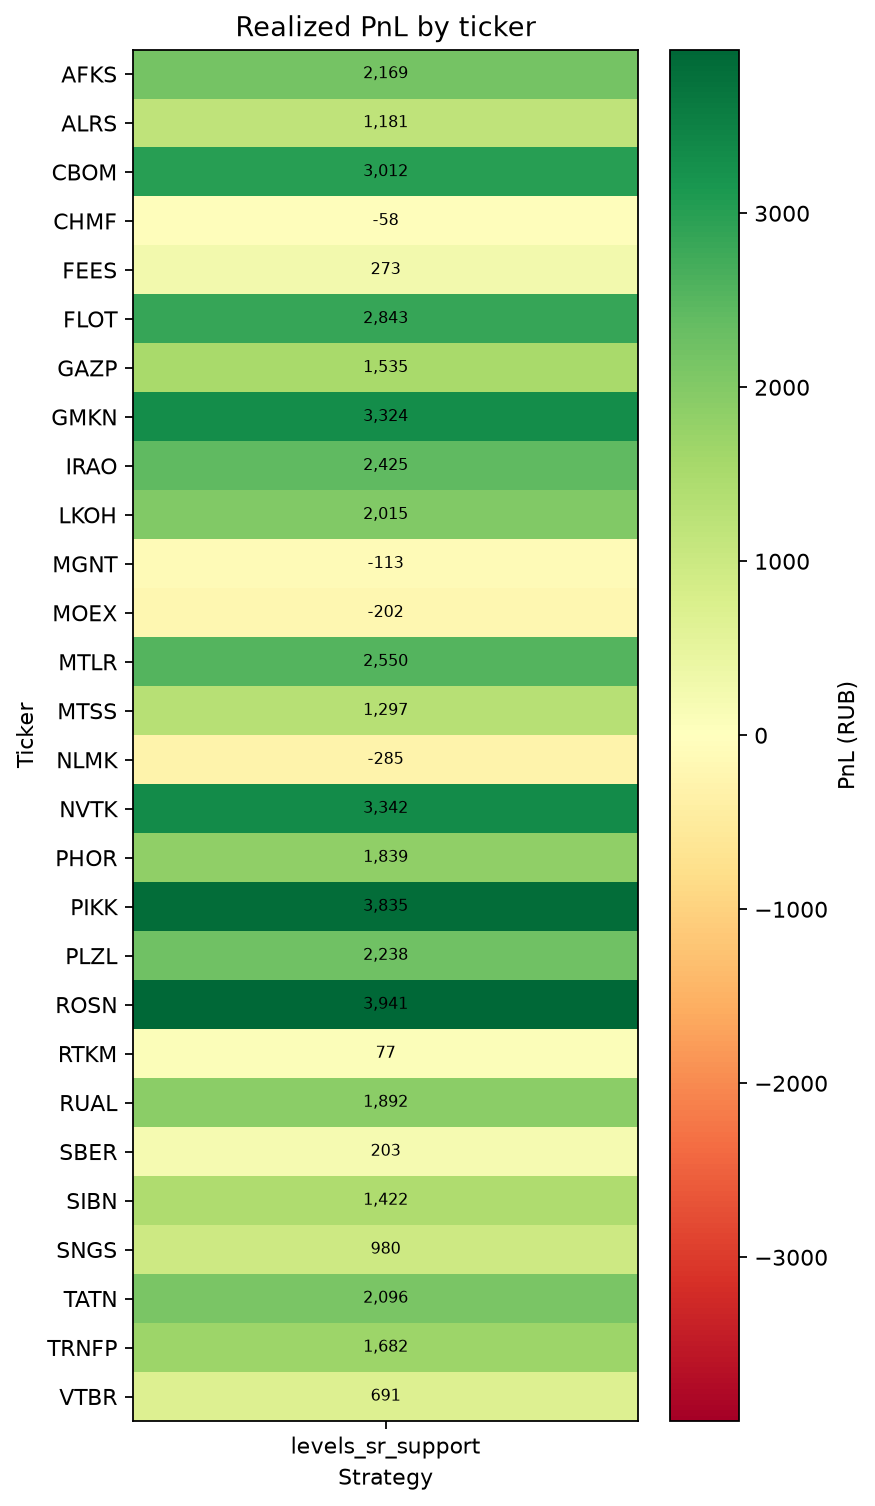

In [6]:
display(analysis['tickers'])
display(Image(filename=str(ANALYSIS_DIR / 'plots/ticker_pnl_heatmap.png')))

## Результаты по месяцам

In [7]:
analysis['monthly']

,month,n_trades,pnl_rub
0,2024-08,37,289.48
1,2024-09,48,2983.82
2,2024-10,42,-1903.15
3,2024-11,65,1855.88
4,2024-12,76,8833.02
5,2025-01,84,1949.05
6,2025-02,132,163.59
7,2025-03,74,-167.59
8,2025-04,147,2334.09
9,2025-05,82,466.55


## Сравнение книг, ALRS и GAME OVER

In [8]:
{
    'verdict': analysis['verdict'],
    'alrs': analysis['alrs'],
    'split': analysis['split'],
    'game_over': analysis['result'].get('game_over'),
    'game_over_ts': analysis['result'].get('game_over_ts'),
    'skipped_entries_no_slot': analysis['result'].get('skipped_entries_no_slot'),
    'issue44': analysis['summary'].get('issue44_context'),
    'issue103': analysis['summary'].get('issue103_context'),
    'issue124_bmix': analysis['summary'].get('issue124_bmix'),
}

{'verdict': {'paper': False,
  'paper_gates_pass': True,
  'match': True,
  'label': 'не paper',
  'reasons': ['Портфель C построен на isolated `levels_sr_support` из #129 (n кандидатов 4380, SHA конфига стабилен), не фильтром source из композита #124.',
   'Слоты 50k / 10k / max 5: n=3237, PF 1.33, equity 96,204.63 RUB, GAME OVER=нет.',
   'Бар ALRS 2026-08-20 11:50 @ 19.80 отсутствует среди candidates и портфельных входов.',
   'Resistance-source n=0 (ожидается 0).',
   'Сравнение с #44/#103 — другие конфиги; #124 B-mix — другой набор кандидатов (support+resistance).',
   'По умолчанию не paper без явного решения Product Owner.']},
 'alrs': {'present': False,
  'found_in_candidates': False,
  'found_in_portfolio_trades': False,
  'timestamp': '2026-08-20 11:50:24',
  'price': 19.8,
  'candidate_hits': [],
  'portfolio_hits': [],
  'blocked': True},
 'split': {'support_n': 3237, 'resistance_n': 0, 'other_n': 0},
 'game_over': False,
 'game_over_ts': None,
 'skipped_entries_no_slot': 1

## Итоговый отчёт

In [9]:
display(Markdown((ANALYSIS_DIR / 'report.md').read_text(encoding='utf-8')))

# Issue #130: портфель 50k levels_sr_support

## Резюме

Конфиг **C** (`levels_sr_support` + `signal_4h_buy`, SHA `3b7864c4de2cb2c7d271be8c21c7d99c29bfd8a7dd05980b3c5497b6b2aedb1b`),
кандидаты из isolated-книги #129 (n=4380).
На общем капитале 50,000 RUB итоговый equity 96,204.63 RUB
(+46,204.63 RUB, +92.41%).
Это исторический бэктест и не доказывает будущую доходность.

**Вердикт для продукта:** не paper. Гейты #44 (PnL>0, PF>1, n≥30, нет GAME OVER) пройдены, но вердикт продукта — **не paper** без явного решения PO.

## Подтверждение конфига C

- Имя: `levels_sr_support`. Lab-черновик не lock/paper-flag.
- Paper / locked: `in_paper_test=false`, `locked=false`.
- Locked `test_20260731` (id=36), swing-only `test_20260820` (id=102) и
  `test_20260821` (id=118) не читались и не записывались.
- Движок кандидатов: `run_strategy_backtest` (пакет #129). На сделках
  `source=levels_sr_support`. Plugin-имя в Lab по-прежнему `levels_reversal`.
- Паттерны: `levels_sr_support, signal_4h_buy`.
- Уровни: `level_method=['swing', 'impulse']`,
  `swing_window=10`,
  `zone_atr_mult=0.5`,
  `level_timeframe=4h`,
  `impulse_body_ratio=0.7`,
  `impulse_atr_mult=1.5`.
- Confirm / RR: `[10]`,
  RR 1.0:2.0,
  commission 0.06%,
  slippage 0.0,
  n_runs `1`.
- Период: `2024-08-01` — `2026-08-20` (запрос `timestamp < 2026-08-21`).
- Вселенная: пересечение `get_big_tickers` с volume-order #103/#44 (28 имён).
- Тикеры в volume-order: `FEES, IRAO, AFKS, VTBR, GAZP, SNGS, SBER, RUAL, ALRS, GMKN, MTLR, CBOM, NLMK, ROSN, RTKM, MOEX, FLOT, MTSS, NVTK, PIKK, TATN, CHMF, SIBN, PLZL, LKOH, TRNFP, MGNT, PHOR`.
- Не загружены: нет.
- SHA конфига C: `3b7864c4de2cb2c7d271be8c21c7d99c29bfd8a7dd05980b3c5497b6b2aedb1b`.
- SHA-256 входного JSON: `0c2ccb5f8cbbd3f8438a050daa6de17f77628d05229ae6ea6aa30df310da8921`.

## Методика

- Кандидаты — isolated C из `analytics/issue-129-sr-support-universe/`
  (**не** exclusive-колонка #124 3811 / 1.51 и **не** `source=`-фильтр композита).
- Капитал 50,000 RUB; слот 10,000 RUB; максимум 5 позиций.
- Конкуренция: статический volume rank; нет слота → skip (`skipped_entries_no_slot`).
- Комиссия уже в `net_return_pct`.
- Equity по дням — по закрытым сделкам, без mark-to-market.
- Max DD в таблице — по equity на конец дня; event-based Max DD симулятора отдельно.
- Isolated PF #129 (1.45) с портфельным PF не смешивать.

## Сравнение книг

| Книга | Что это | Equity, RUB | n | PF | Max DD | GAME OVER |
|---|---|---:|---:|---:|---:|:---:|
| #44 `test_20260731` | портфель до вето, `date_to=2026-08-15` | 96,343.49 | 3500 | 1.31 | 5.47% | нет |
| #103 `test_20260821` | портфель после вето, без трекера | 89,055.31 | 2070 | 1.34 | 6.82% | нет |
| C `levels_sr_support` | эта задача, вето **с** трекером, без ретеста | 96,204.63 | 3237 | 1.33 | 6.08% | нет |
| #124 B-mix | композит support+resistance, другой набор кандидатов | 98,432.94 | 2837 | 1.32 | 7.93%* | нет |

\* у B-mix в пакете #124 опубликован event-based Max DD симулятора, не daily.

Isolated C (не портфель): n=4380, PF 1.45. Exclusive B-support 3811 / 1.51 в портфель не брался.

## Портфельные метрики C

| Стратегия | Итоговый equity, RUB | PnL, RUB | PnL, % | Сделки | Win rate | Profit factor | Max DD | GAME OVER |
|---|---:|---:|---:|---:|---:|---:|---:|:---:|
| levels_sr_support | 96,204.63 | +46,204.63 | +92.41% | 3237 | 28.7% | 1.33 | 6.08% | нет |

- skipped no-slot: `1143`.
- candidate trades до replay: `4380`.
- source: support n=3237, resistance n=0.

![Equity curve](plots/equity_curves.png)

### Максимальная просадка

- Daily Max DD: 6.08% с 2025-02-17
  по 2025-03-13; equity снизилась с
  66,889.89 до
  62,820.64 RUB
  (−4,069.25 RUB).
- Event-based Max DD симулятора: 6.98%.

## Анализ сделок и тикеров

![Trade PnL distribution](plots/trade_pnl_distribution.png)

![Ticker PnL heatmap](plots/ticker_pnl_heatmap.png)

- **Больше всего сделок:** CBOM (209 сделок), FLOT (200 сделок), PHOR (184 сделок), MOEX (141 сделок), IRAO (137 сделок).
- **Прибыльные:** ROSN (+3,941 RUB, 129 сделок), PIKK (+3,835 RUB, 106 сделок), NVTK (+3,342 RUB, 108 сделок), GMKN (+3,324 RUB, 91 сделок), CBOM (+3,012 RUB, 209 сделок).
- **Убыточные:** NLMK (-285 RUB, 99 сделок), MOEX (-202 RUB, 141 сделок), MGNT (-113 RUB, 98 сделок), CHMF (-58 RUB, 75 сделок).

## Анализ по месяцам

- Прибыльные месяцы — 2024-08, 2024-09, 2024-11, 2024-12, 2025-01, 2025-02, 2025-04, 2025-05, 2025-06, 2025-07, 2025-08, 2025-10, 2025-11, 2025-12, 2026-01, 2026-03, 2026-04, 2026-05, 2026-06, 2026-07, 2026-08; убыточные — 2024-10, 2025-03, 2025-09, 2026-02.

## Точечная проверка ALRS (paper #711)

Бар `2026-08-20 11:50:24` @ 19.80 **не** найден ни среди candidate entries, ни среди портфельных сделок. Вето #97 на этом баре сработало.

## GAME OVER

GAME OVER не наступил.

## Рекомендации

1. не paper: Гейты #44 (PnL>0, PF>1, n≥30, нет GAME OVER) пройдены, но вердикт продукта — **не paper** без явного решения PO.
2. Не подменять этот портфель isolated PF #129 и не смешивать с #124 B-mix.
3. Не lock/overwrite `test_20260731`, `test_20260820`, `test_20260821`.
4. Черновик Lab, если понадобится: `test_YYYYMMDD_sr_support` — не перезаписывать чужие строки.

## Воспроизводимость

- SHA конфига C: `3b7864c4de2cb2c7d271be8c21c7d99c29bfd8a7dd05980b3c5497b6b2aedb1b`
- Входной JSON SHA-256: `0c2ccb5f8cbbd3f8438a050daa6de17f77628d05229ae6ea6aa30df310da8921`
- Код расчётов: `analysis.py`; интерактивный walkthrough: `analysis.ipynb`.

![Metrics summary](plots/metrics_comparison.png)


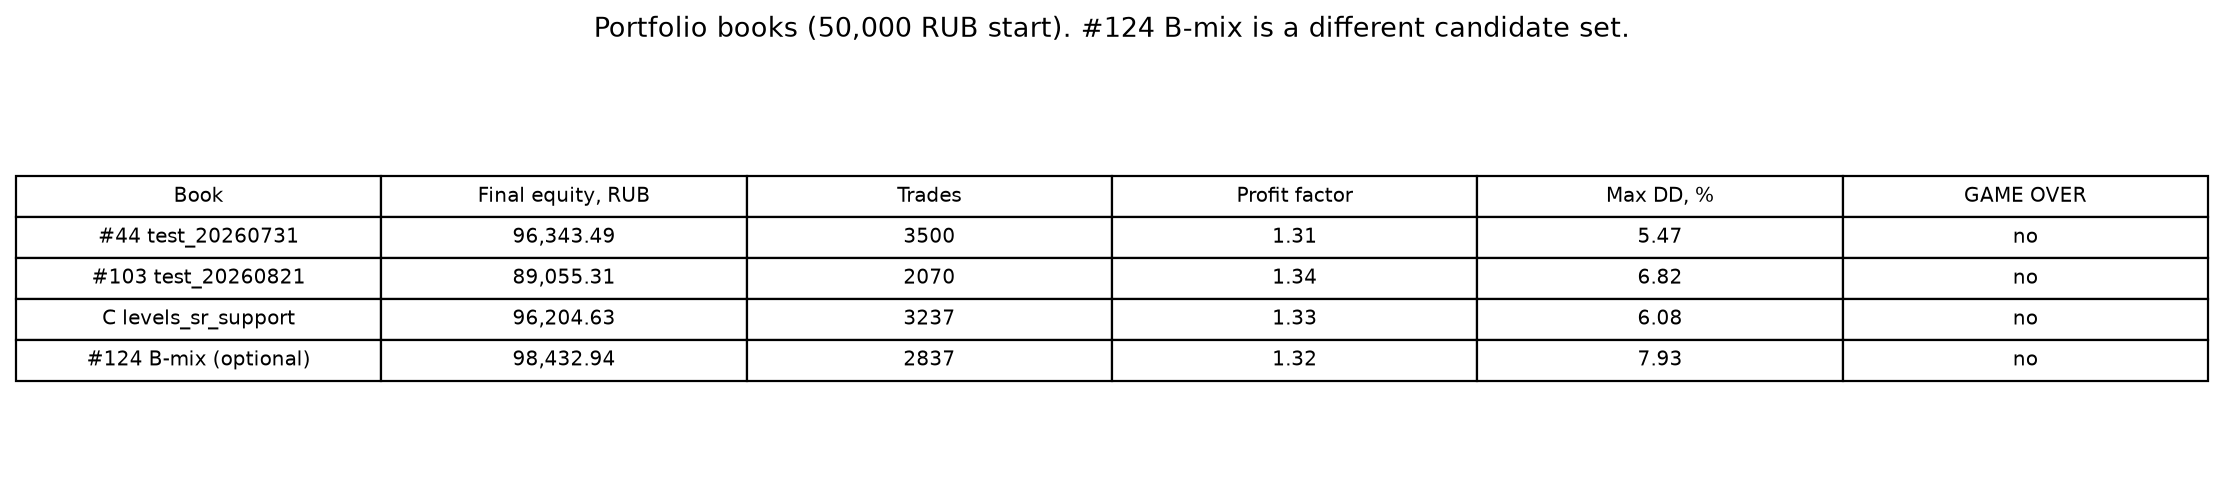

In [10]:
display(Image(filename=str(ANALYSIS_DIR / 'plots/metrics_comparison.png')))